In [14]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from scipy.stats import gaussian_kde

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [15]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'speed-accuracy_trade-off')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [16]:
# Preparation
pilot_analysis = True
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
    unique_subject_ids = [802,803,804,805,806,807,808,809,810,811,813,814,815]
    unique_sessions = [1]
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
    unique_subject_ids = [5, 10, 11, 14]
    unique_sessions = [2, 3, 4]

# Load and combine the datasets
combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, pilot_analysis, binary_output=False)

['/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-802_session-01_dummy_2024-09-10_11-06-48.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-803_session-01_dummy_2024-09-10_13-40-11.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-804_session-01_dummy_2024-09-10_15-41-26.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-805_session-01_dummy_2024-09-11_09-08-32.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-806_session-01_dummy_2024-09-11_11-12-35.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-807_session-01_dummy_2024-09-11_13-42-58.csv', '/Volumes

# Inverse efficiency score
IES = subject's average RT (ms) / 1 - proportion of errors (0.10 for example)

In [17]:
IES_dataframe = utils.analysis_functions.calculate_IES(combined_results_dataframe)
IES_dataframe_congruency = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['congruency'])
IES_dataframe_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['volatility'])
IES_dataframe_congruency_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['congruency', 'volatility'])

   subject_id     session      RT_s  objectively_correct_boolean  \
0     sub-802  session-01  0.728298                     0.687405   
1     sub-803  session-01  0.743008                     0.769697   
2     sub-804  session-01  0.709226                     0.603030   
3     sub-805  session-01  0.687887                     0.721212   
4     sub-806  session-01  0.797172                     0.800000   
5     sub-807  session-01  0.737467                     0.529590   
6     sub-808  session-01  0.721432                     0.662121   
7     sub-809  session-01  0.715199                     0.716667   
8     sub-810  session-01  0.726374                     0.554531   
9     sub-811  session-01  0.664921                     0.763636   
10    sub-813  session-01  0.769439                     0.739394   
11    sub-814  session-01  0.705232                     0.777273   
12    sub-815  session-01  0.739961                     0.658574   

    objectively_incorrect_boolean       IES  
0

# Plot the relation between speed and accuracy
Quantile probability function

In [18]:
quadratic_trend = False

In [19]:
# suppose your original DataFrame is called df
summary = (
    combined_results_dataframe
    .groupby(['subject_id', 'session', 'congruency'])
    .agg(
        mean_reaction_time=('RT_s', 'mean'),
        mean_performance=('objectively_correct_boolean', 'mean')
    )
    .reset_index()
)

print(summary)

   subject_id     session   congruency  mean_reaction_time  mean_performance
0     sub-802  session-01    congruent            0.715724          0.814815
1     sub-802  session-01  incongruent            0.780461          0.542208
2     sub-803  session-01    congruent            0.750482          0.765244
3     sub-803  session-01  incongruent            0.753036          0.774096
4     sub-804  session-01    congruent            0.714593          0.734568
5     sub-804  session-01  incongruent            0.735298          0.476190
6     sub-805  session-01    congruent            0.674884          0.806818
7     sub-805  session-01  incongruent            0.743198          0.623377
8     sub-806  session-01    congruent            0.783241          0.801205
9     sub-806  session-01  incongruent            0.821229          0.798780
10    sub-807  session-01    congruent            0.765930          0.568807
11    sub-807  session-01  incongruent            0.794479          0.490964

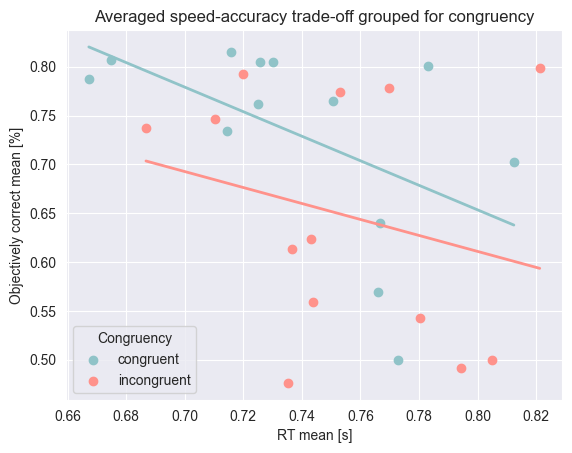

In [20]:
x_col = 'mean_reaction_time'
y_col = 'mean_performance'
group_col = 'congruency'

# Define colours for each group
colour_map = {
    'congruent':   '#90C3C8',
    'incongruent': '#FF928B',
}

fig, ax = plt.subplots()

for cong, group in summary.groupby(group_col):
    x = group[x_col].values
    y = group[y_col].values
    col = colour_map.get(cong, 'gray')

    # Only the scatter gets a legend label
    ax.scatter(x, y, color=col, label=cong)

    # Fit a trendline
    if quadratic_trend:
        a, b, c = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = a*x_smooth**2 + b*x_smooth + c

        ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
    else:
        m, c = np.polyfit(x, y, deg=1)
        x_line = np.array([x.min(), x.max()])
        y_line = m*x_line + c

        ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

ax.set_xlabel('RT mean [s]')
ax.set_ylabel('Objectively correct mean [%]')
plot_name = 'Averaged speed-accuracy trade-off grouped for congruency'
ax.set_title(plot_name)
ax.legend(title='Congruency')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

In [21]:
# suppose your original DataFrame is called df
summary = (
    combined_results_dataframe
    .groupby(['subject_id', 'session', 'volatility'])
    .agg(
        mean_reaction_time=('RT_s', 'mean'),
        mean_performance=('objectively_correct_boolean', 'mean')
    )
    .reset_index()
)

print(summary)

   subject_id     session volatility  mean_reaction_time  mean_performance
0     sub-802  session-01     stable            0.764899          0.694823
1     sub-802  session-01   volatile            0.722202          0.678082
2     sub-803  session-01     stable            0.755293          0.852151
3     sub-803  session-01   volatile            0.747212          0.663194
4     sub-804  session-01     stable            0.707338          0.612637
5     sub-804  session-01   volatile            0.747017          0.591216
6     sub-805  session-01     stable            0.718701          0.730978
7     sub-805  session-01   volatile            0.691719          0.708904
8     sub-806  session-01     stable            0.804533          0.845109
9     sub-806  session-01   volatile            0.799079          0.743151
10    sub-807  session-01     stable            0.789864          0.548913
11    sub-807  session-01   volatile            0.768234          0.505155
12    sub-808  session-01

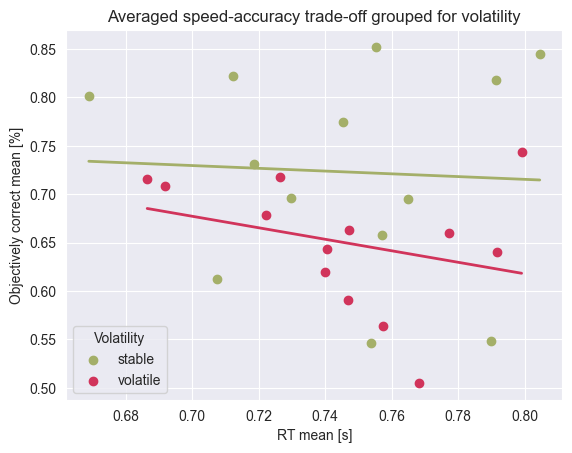

In [22]:
x_col = 'mean_reaction_time'
y_col = 'mean_performance'
group_col = 'volatility'

# Define colours for each group
colour_map = {
    'stable':   '#A4AF69',
    'volatile': '#D1345B',
}

fig, ax = plt.subplots()

for cong, group in summary.groupby(group_col):
    x = group[x_col].values
    y = group[y_col].values
    col = colour_map.get(cong, 'gray')

    # Only the scatter gets a legend label
    ax.scatter(x, y, color=col, label=cong)

    # Fit a trendline
    if quadratic_trend:
        a, b, c = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = a*x_smooth**2 + b*x_smooth + c

        ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
    else:
        m, c = np.polyfit(x, y, deg=1)
        x_line = np.array([x.min(), x.max()])
        y_line = m*x_line + c

        ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

ax.set_xlabel('RT mean [s]')
ax.set_ylabel('Objectively correct mean [%]')
plot_name = 'Averaged speed-accuracy trade-off grouped for volatility'
ax.set_title(plot_name)
ax.legend(title='Volatility')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

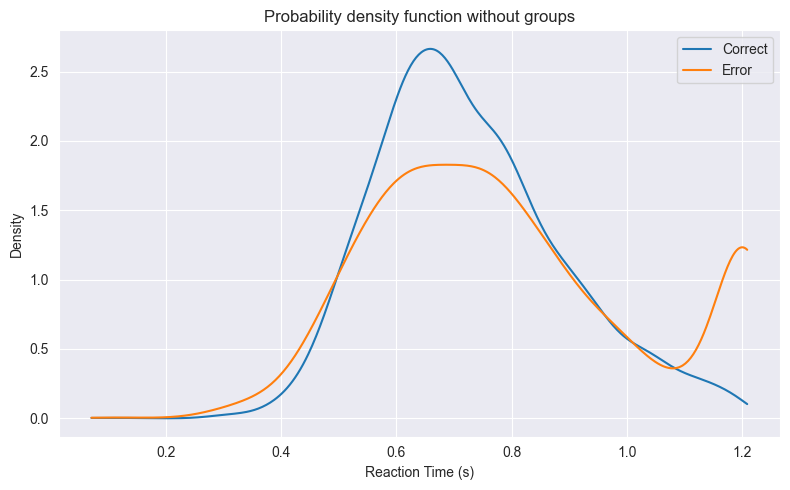

In [23]:
# assume `df` is your DataFrame
# split RTs by correctness
rts_correct = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 1, 'RT_s']
rts_error   = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 0, 'RT_s']

# compute KDEs
kde_correct = gaussian_kde(rts_correct)
kde_error   = gaussian_kde(rts_error)

# choose a common x‐axis range
xmin, xmax = combined_results_dataframe['RT_s'].min(), combined_results_dataframe['RT_s'].max()
x_vals = np.linspace(xmin, xmax, 500)

# plot both densities
plt.figure(figsize=(8, 5))
plt.plot(x_vals, kde_correct(x_vals), label='Correct')
plt.plot(x_vals, kde_error(  x_vals), label='Error')
plt.xlabel('Reaction Time (s)')
plt.ylabel('Density')
plot_name = 'Probability density function without groups'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

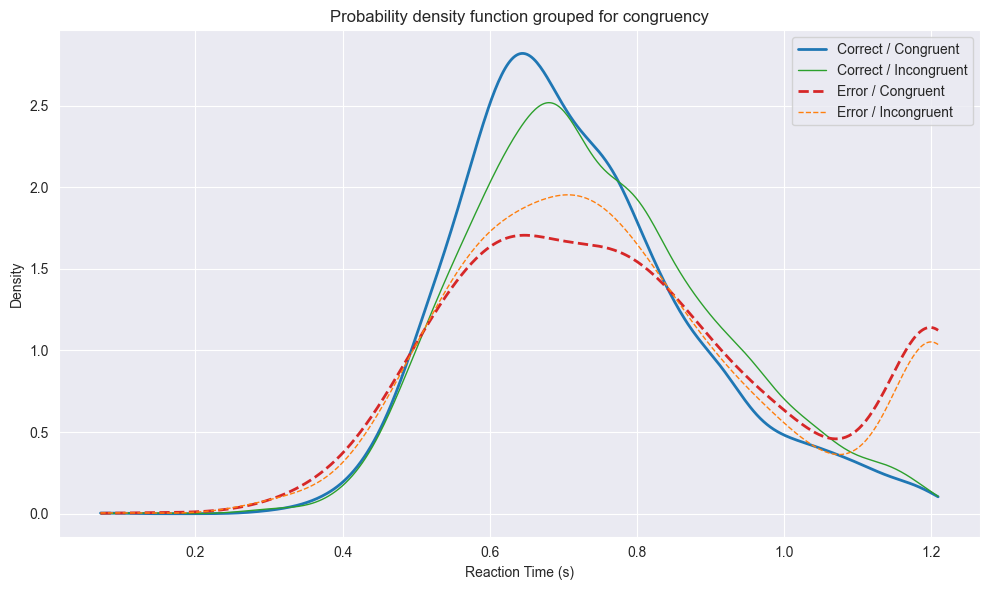

In [24]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['congruent', 'incongruent']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'congruent'):   'tab:blue',
    (1, 'incongruent'): 'tab:green',
    (0, 'congruent'):   'tab:red',
    (0, 'incongruent'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_s'].min(), combined_results_dataframe['RT_s'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for cong in ['congruent', 'incongruent']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['congruency'] == cong)
        ]['RT_s']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {cong.capitalize()}"
        c = color_map[(obj_val, cong)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if cong == 'congruent' else 1)

# finalize
plt.xlabel('Reaction Time (s)')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for congruency'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

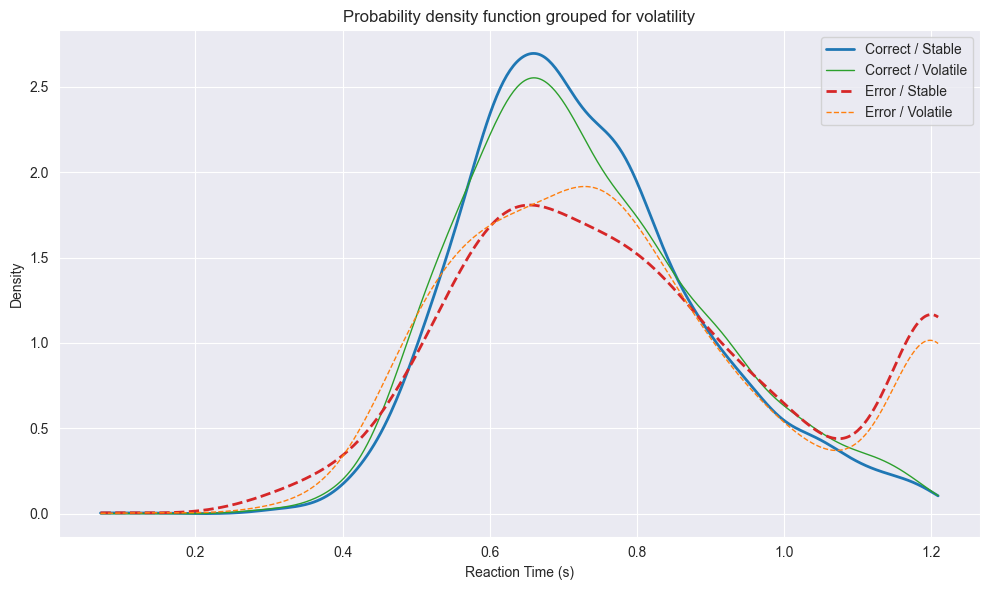

In [25]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['stable', 'volatile']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'stable'):   'tab:blue',
    (1, 'volatile'): 'tab:green',
    (0, 'stable'):   'tab:red',
    (0, 'volatile'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_s'].min(), combined_results_dataframe['RT_s'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for volatility in ['stable', 'volatile']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['volatility'] == volatility)
        ]['RT_s']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {volatility.capitalize()}"
        c = color_map[(obj_val, volatility)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if volatility == 'stable' else 1)

# finalize
plt.xlabel('Reaction Time (s)')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for volatility'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

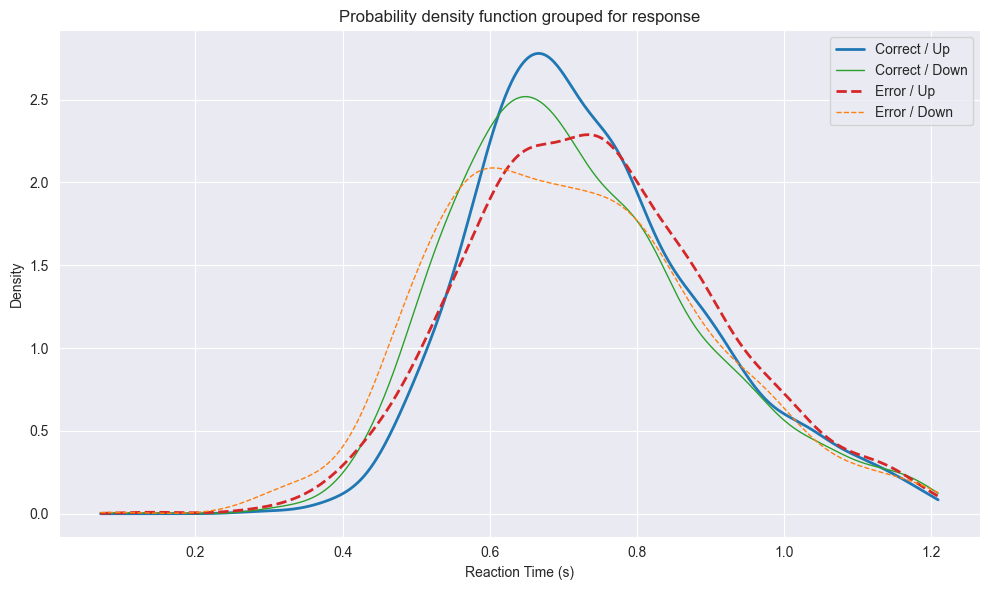

In [26]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['up', 'down']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'up'):   'tab:blue',
    (1, 'down'): 'tab:green',
    (0, 'up'):   'tab:red',
    (0, 'down'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_s'].min(), combined_results_dataframe['RT_s'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for response_direction in ['up', 'down']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['response'] == response_direction)
        ]['RT_s']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {response_direction.capitalize()}"
        c = color_map[(obj_val, response_direction)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if response_direction == 'up' else 1)

# finalize
plt.xlabel('Reaction Time (s)')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for response'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()